# Assignment 2
**Clay Ramey**

**COMP 6630**

## Resources Used

I used lecture notes from the COMP-6630 class. I also used Claude AI to help build visualizations, help me understand how to write different functions and their purpose, clean up markdown comments for clarity, and the use of scikit-learn. I also used GeekforGeeks scikit-learn docs help as well as basic google searches and YouTube for concepts I wanted to understand better.

## Part 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

print(f"shape of X: {X.shape}")
print(f"shape of y: {y.shape}")
print(f"\nfeature cols: {feature_names}")

shape of X: (150, 4)
shape of y: (150,)

feature cols: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
# distribution of target classes
unique, counts = np.unique(y, return_counts=True)
print("\ndistribution of target classes:")
for cls, count in zip(unique, counts):
    print(f"class {cls}: {count} samples")


distribution of target classes:
class 0: 50 samples
class 1: 50 samples
class 2: 50 samples


In [5]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=15, stratify=y
)

print(f"\ntraining set size: {X_train.shape[0]}")
print(f"testing set size: {X_test.shape[0]}")


training set size: 120
testing set size: 30


In [7]:
# standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nfeatures standardized successfully")
print(f"mean of scaled training features: {X_train_scaled.mean(axis=0)}")
print(f"std of scaled training features: {X_train_scaled.std(axis=0)}")


features standardized successfully
mean of scaled training features: [2.77694534e-15 5.42899059e-15 1.99840144e-16 1.27675648e-16]
std of scaled training features: [1. 1. 1. 1.]


In [9]:
# create binary classification problems for each class
y_train_binary = {}
y_test_binary = {}

for c in [0, 1, 2]:
    y_train_binary[c] = (y_train == c).astype(int)
    y_test_binary[c] = (y_test == c).astype(int)
    print(f"\nclass {c} vs rest:")
    print(f"\ttraining: {y_train_binary[c].sum()} positive, {len(y_train_binary[c]) - y_train_binary[c].sum()} negative")
    print(f"\ttesting: {y_test_binary[c].sum()} positive, {len(y_test_binary[c]) - y_test_binary[c].sum()} negative")


class 0 vs rest:
	training: 40 positive, 80 negative
	testing: 10 positive, 20 negative

class 1 vs rest:
	training: 40 positive, 80 negative
	testing: 10 positive, 20 negative

class 2 vs rest:
	training: 40 positive, 80 negative
	testing: 10 positive, 20 negative


## Part 2

In [10]:
def sigmoid(z):
    # sigmoid function
    return 1 / (1 + np.exp(-z))

def compute_log_likelihood(X, y, w):
    # compute log-likelihood loss
    z = X @ w
    y_pred = sigmoid(z)
    # clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    log_likelihood = np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return log_likelihood

def compute_gradient(X, y, w):
    # compute gradient of log-likelihood
    z = X @ w
    y_pred = sigmoid(z)
    gradient = X.T @ (y - y_pred)
    return gradient

def gradient_ascent(X, y, learning_rate=0.0001, n_iterations=10000):
    # initialize weights with zeros
    n_features = X.shape[1]
    w = np.zeros(n_features)
    
    # store loss history
    loss_history = []
    
    for i in range(n_iterations):
        # compute gradient
        gradient = compute_gradient(X, y, w)
        
        # update weights
        w = w + learning_rate * gradient
        
        # compute and store loss every 100 iterations
        if i % 100 == 0:
            loss = compute_log_likelihood(X, y, w)
            loss_history.append(loss)
    
    return w, loss_history

def predict(X, w):
    # make predictions
    z = X @ w
    y_pred = sigmoid(z)
    return (y_pred >= 0.5).astype(int)

In [12]:
# train logistic regression for each class using gradient ascent
manual_models = {}
loss_histories = {}
manual_train_accuracies = {}
manual_test_accuracies = {}

for c in [0, 1, 2]:
    print(f"\ntraining class {c} vs rest with gradient ascent")
    
    # train model
    w, loss_history = gradient_ascent(
        X_train_scaled, 
        y_train_binary[c], 
        learning_rate=0.0001, 
        n_iterations=10000
    )
    
    manual_models[c] = w
    loss_histories[c] = loss_history
    
    # compute training accuracy
    train_pred = predict(X_train_scaled, w)
    train_acc = accuracy_score(y_train_binary[c], train_pred)
    manual_train_accuracies[c] = train_acc
    
    # compute test accuracy
    test_pred = predict(X_test_scaled, w)
    test_acc = accuracy_score(y_test_binary[c], test_pred)
    manual_test_accuracies[c] = test_acc
    
    print(f"  train accuracy: {train_acc:.4f}")
    print(f"  test accuracy: {test_acc:.4f}")
    print(f"  final log-likelihood: {loss_history[-1]:.4f}")


training class 0 vs rest with gradient ascent
  train accuracy: 1.0000
  test accuracy: 1.0000
  final log-likelihood: -3.6257

training class 1 vs rest with gradient ascent
  train accuracy: 0.7083
  test accuracy: 0.7333
  final log-likelihood: -69.4234

training class 2 vs rest with gradient ascent
  train accuracy: 0.8250
  test accuracy: 0.9333
  final log-likelihood: -42.1837


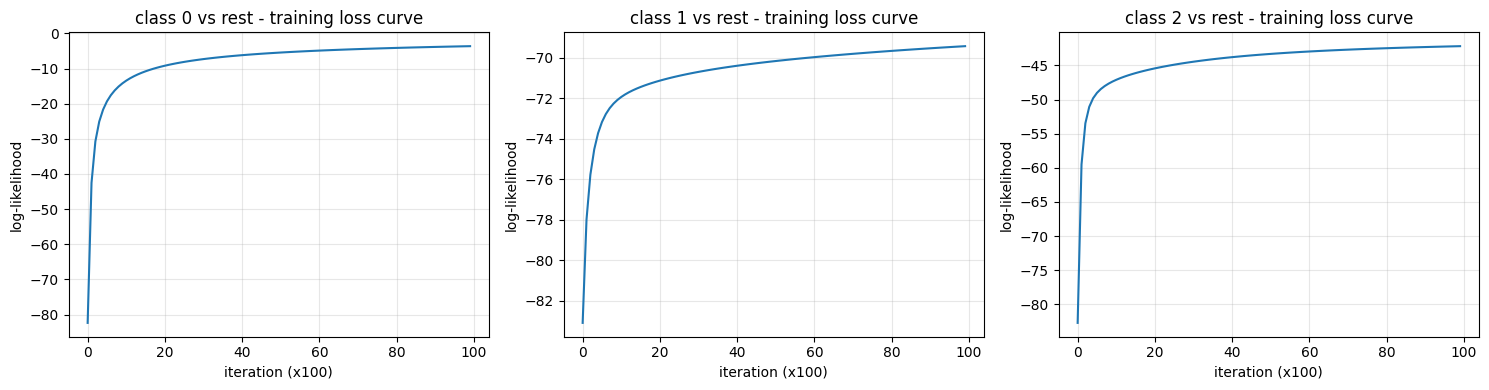

In [13]:
# plot training loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, c in enumerate([0, 1, 2]):
    axes[idx].plot(loss_histories[c])
    axes[idx].set_xlabel('iteration (x100)')
    axes[idx].set_ylabel('log-likelihood')
    axes[idx].set_title(f'class {c} vs rest - training loss curve')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 3

In [17]:
# train logistic regression models with no regularization
sklearn_models_no_reg = {}
sklearn_train_acc_no_reg = {}
sklearn_test_acc_no_reg = {}
weights_no_reg = {}
top_features_no_reg = {}

for c in [0, 1, 2]:
    print(f"\ntraining class {c} vs rest (no regularization)")
    
    # train model
    model = LogisticRegression(penalty=None, max_iter=10000, random_state=15)
    model.fit(X_train_scaled, y_train_binary[c])
    
    sklearn_models_no_reg[c] = model
    
    # extract feature weights
    weights = model.coef_[0]
    weights_no_reg[c] = weights
    
    # rank features by absolute weight
    abs_weights = np.abs(weights)
    feature_importance = list(zip(feature_names, weights, abs_weights))
    feature_importance.sort(key=lambda x: x[2], reverse=True)
    
    top_features_no_reg[c] = feature_importance[:3]
    
    print(f"\n\ttop 3 features:")
    for i, (feat, weight, abs_weight) in enumerate(feature_importance[:3], 1):
        print(f"\t{i}. {feat}: weight = {weight:.4f}, abs(weight) = {abs_weight:.4f}")
    
    # compute accuracies
    train_acc = model.score(X_train_scaled, y_train_binary[c])
    test_acc = model.score(X_test_scaled, y_test_binary[c])
    
    sklearn_train_acc_no_reg[c] = train_acc
    sklearn_test_acc_no_reg[c] = test_acc
    
    print(f"\n\ttraining accuracy: {train_acc:.4f}")
    print(f"\ttest accuracy: {test_acc:.4f}")


training class 0 vs rest (no regularization)

	top 3 features:
	1. petal length (cm): weight = -5.7374, abs(weight) = 5.7374
	2. petal width (cm): weight = -4.7711, abs(weight) = 4.7711
	3. sepal width (cm): weight = 2.8635, abs(weight) = 2.8635

	training accuracy: 1.0000
	test accuracy: 1.0000

training class 1 vs rest (no regularization)

	top 3 features:
	1. petal length (cm): weight = 3.6411, abs(weight) = 3.6411
	2. petal width (cm): weight = -2.8968, abs(weight) = 2.8968
	3. sepal width (cm): weight = -0.9660, abs(weight) = 0.9660

	training accuracy: 0.7417
	test accuracy: 0.8333

training class 2 vs rest (no regularization)

	top 3 features:
	1. petal width (cm): weight = 139.3772, abs(weight) = 139.3772
	2. petal length (cm): weight = 80.5595, abs(weight) = 80.5595
	3. sepal width (cm): weight = -21.6212, abs(weight) = 21.6212

	training accuracy: 1.0000
	test accuracy: 0.9000


In [18]:
# create feature weight tables for each class
print("feature weight tables (no regularization)")

for c in [0, 1, 2]:
    print(f"\nclass {c} vs rest:")
    df = pd.DataFrame({
        'feature': feature_names,
        'weight': weights_no_reg[c],
        'abs(weight)': np.abs(weights_no_reg[c])
    })
    df = df.sort_values('abs(weight)', ascending=False)
    print(df.to_string(index=False))

feature weight tables (no regularization)

class 0 vs rest:
          feature    weight  abs(weight)
petal length (cm) -5.737384     5.737384
 petal width (cm) -4.771110     4.771110
 sepal width (cm)  2.863474     2.863474
sepal length (cm) -1.689983     1.689983

class 1 vs rest:
          feature    weight  abs(weight)
petal length (cm)  3.641080     3.641080
 petal width (cm) -2.896791     2.896791
 sepal width (cm) -0.966007     0.966007
sepal length (cm) -0.672719     0.672719

class 2 vs rest:
          feature     weight  abs(weight)
 petal width (cm) 139.377232   139.377232
petal length (cm)  80.559541    80.559541
 sepal width (cm) -21.621219    21.621219
sepal length (cm)  -5.405448     5.405448



confusion matrix on test set (no regularization):
[[10  0  0]
 [ 0 10  0]
 [ 0  3  7]]


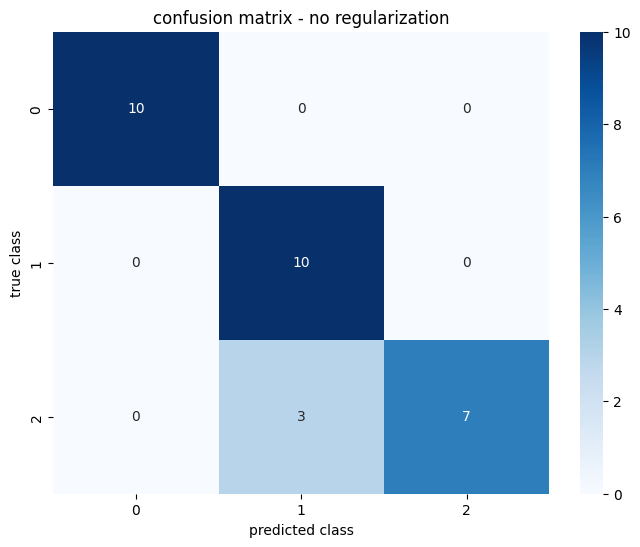


multiclass test accuracy (no regularization): 0.9000


In [19]:
# compute confusion matrix on test set for multiclass prediction
# use the three OvR classifiers to make multiclass predictions
test_predictions = np.zeros((len(X_test_scaled), 3))

for c in [0, 1, 2]:
    test_predictions[:, c] = sklearn_models_no_reg[c].decision_function(X_test_scaled)

# predict class with highest score
y_pred_multiclass = np.argmax(test_predictions, axis=1)

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred_multiclass)

print("\nconfusion matrix on test set (no regularization):")
print(cm)

# visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel('predicted class')
plt.ylabel('true class')
plt.title('confusion matrix - no regularization')
plt.show()

multiclass_accuracy = accuracy_score(y_test, y_pred_multiclass)
print(f"\nmulticlass test accuracy (no regularization): {multiclass_accuracy:.4f}")

## Part 4

In [20]:
# train logistic regression models with L1 regularization
sklearn_models_l1 = {}
sklearn_train_acc_l1 = {}
sklearn_test_acc_l1 = {}
weights_l1 = {}
top_features_l1 = {}

for c in [0, 1, 2]:
    print(f"\ntraining class {c} vs rest (L1 regularization)")
    
    # train model with L1 regularization
    model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=15)
    model.fit(X_train_scaled, y_train_binary[c])
    
    sklearn_models_l1[c] = model
    
    # extract feature weights
    weights = model.coef_[0]
    weights_l1[c] = weights
    
    # identify zeroed features
    zeroed_count = np.sum(np.abs(weights) < 1e-10)
    print(f"\tfeatures zeroed out: {zeroed_count} out of {len(weights)}")
    
    # rank features by absolute weight
    abs_weights = np.abs(weights)
    feature_importance = list(zip(feature_names, weights, abs_weights))
    feature_importance.sort(key=lambda x: x[2], reverse=True)
    
    top_features_l1[c] = feature_importance[:3]
    
    print(f"\n\ttop 3 features (L1):")
    for i, (feat, weight, abs_weight) in enumerate(feature_importance[:3], 1):
        print(f"    {i}. {feat}: weight = {weight:.4f}, abs(weight) = {abs_weight:.4f}")
    
    # compute accuracies
    train_acc = model.score(X_train_scaled, y_train_binary[c])
    test_acc = model.score(X_test_scaled, y_test_binary[c])
    
    sklearn_train_acc_l1[c] = train_acc
    sklearn_test_acc_l1[c] = test_acc
    
    print(f"\n\ttraining accuracy: {train_acc:.4f}")
    print(f"\ttest accuracy: {test_acc:.4f}")


training class 0 vs rest (L1 regularization)
	features zeroed out: 2 out of 4

	top 3 features (L1):
    1. petal length (cm): weight = -1.9808, abs(weight) = 1.9808
    2. sepal width (cm): weight = 0.2334, abs(weight) = 0.2334
    3. sepal length (cm): weight = 0.0000, abs(weight) = 0.0000

	training accuracy: 1.0000
	test accuracy: 0.9667

training class 1 vs rest (L1 regularization)
	features zeroed out: 3 out of 4

	top 3 features (L1):
    1. sepal width (cm): weight = -0.5327, abs(weight) = 0.5327
    2. sepal length (cm): weight = 0.0000, abs(weight) = 0.0000
    3. petal length (cm): weight = 0.0000, abs(weight) = 0.0000

	training accuracy: 0.6917
	test accuracy: 0.8667

training class 2 vs rest (L1 regularization)
	features zeroed out: 3 out of 4

	top 3 features (L1):
    1. petal width (cm): weight = 1.5021, abs(weight) = 1.5021
    2. sepal length (cm): weight = 0.0000, abs(weight) = 0.0000
    3. sepal width (cm): weight = 0.0000, abs(weight) = 0.0000

	training accurac

In [21]:
# create comparison tables for each class
print("feature weight comparing no regularization to l1 regularization")

for c in [0, 1, 2]:
    print(f"\nclass {c} vs rest:")
    
    # create comparison dataframe
    df = pd.DataFrame({
        'feature': feature_names,
        'weight (no reg)': weights_no_reg[c],
        'abs(weight)': np.abs(weights_no_reg[c]),
        'weight (L1)': weights_l1[c],
        'zeroed?': ['yes' if abs(w) < 1e-10 else 'no' for w in weights_l1[c]]
    })
    
    # sort by absolute weight of no regularization model
    df = df.sort_values('abs(weight)', ascending=False)
    print(df.to_string(index=False))

feature weight comparing no regularization to l1 regularization

class 0 vs rest:
          feature  weight (no reg)  abs(weight)  weight (L1) zeroed?
petal length (cm)        -5.737384     5.737384    -1.980847      no
 petal width (cm)        -4.771110     4.771110     0.000000     yes
 sepal width (cm)         2.863474     2.863474     0.233354      no
sepal length (cm)        -1.689983     1.689983     0.000000     yes

class 1 vs rest:
          feature  weight (no reg)  abs(weight)  weight (L1) zeroed?
petal length (cm)         3.641080     3.641080     0.000000     yes
 petal width (cm)        -2.896791     2.896791     0.000000     yes
 sepal width (cm)        -0.966007     0.966007    -0.532713      no
sepal length (cm)        -0.672719     0.672719     0.000000     yes

class 2 vs rest:
          feature  weight (no reg)  abs(weight)  weight (L1) zeroed?
 petal width (cm)       139.377232   139.377232     1.502136      no
petal length (cm)        80.559541    80.559541     0.

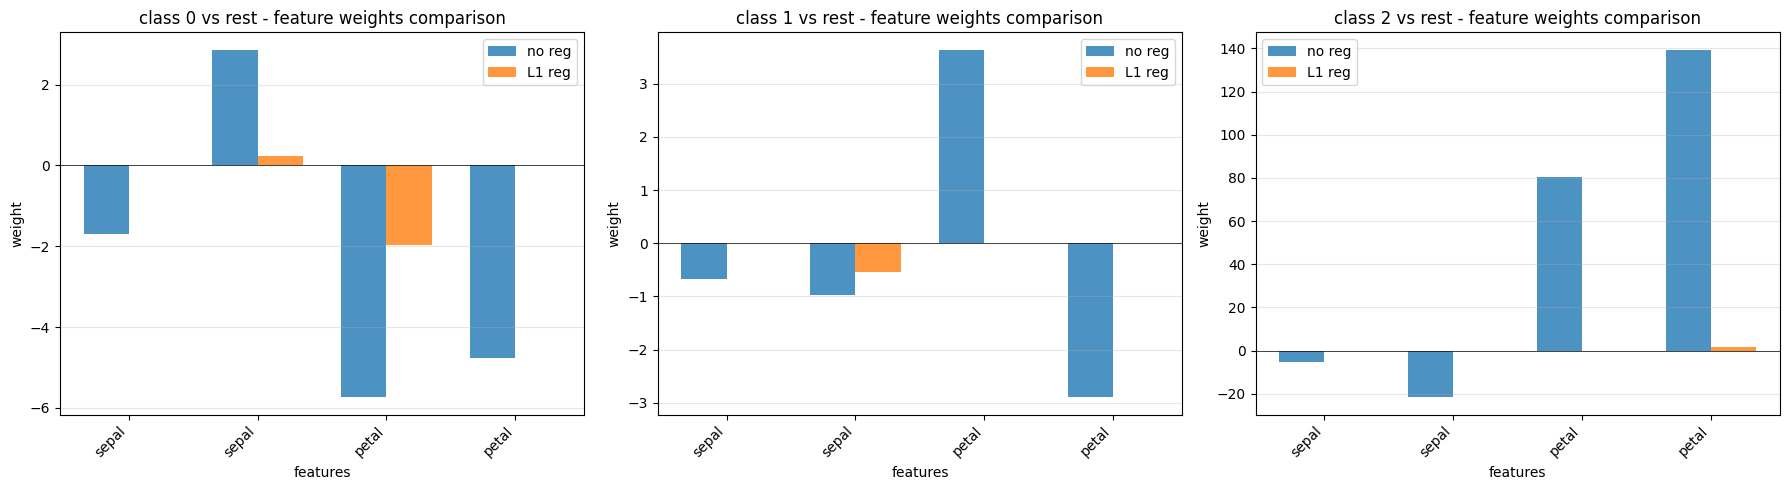

In [22]:
# visualize weight comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, c in enumerate([0, 1, 2]):
    x_pos = np.arange(len(feature_names))
    width = 0.35
    
    axes[idx].bar(x_pos - width/2, weights_no_reg[c], width, label='no reg', alpha=0.8)
    axes[idx].bar(x_pos + width/2, weights_l1[c], width, label='L1 reg', alpha=0.8)
    
    axes[idx].set_xlabel('features')
    axes[idx].set_ylabel('weight')
    axes[idx].set_title(f'class {c} vs rest - feature weights comparison')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels([f.split()[0] for f in feature_names], rotation=45, ha='right')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## Part 5

In [28]:
# performance comparison table
print("performance comparison")

performance_data = []

for c in [0, 1, 2]:
    performance_data.append({
        'class': f'{c} vs rest',
        'manual train acc,': f"{manual_train_accuracies[c]:.4f}",
        'manual test acc,': f"{manual_test_accuracies[c]:.4f}",
        'no reg train acc,': f"{sklearn_train_acc_no_reg[c]:.4f}",
        'no reg test acc,': f"{sklearn_test_acc_no_reg[c]:.4f}",
        'L1 train acc,': f"{sklearn_train_acc_l1[c]:.4f}",
        'L1 test acc,': f"{sklearn_test_acc_l1[c]:.4f}"
    })

df_performance = pd.DataFrame(performance_data)
print(df_performance.to_string(index=False))

performance comparison
    class manual train acc, manual test acc, no reg train acc, no reg test acc, L1 train acc, L1 test acc,
0 vs rest            1.0000           1.0000            1.0000           1.0000        1.0000       0.9667
1 vs rest            0.7083           0.7333            0.7417           0.8333        0.6917       0.8667
2 vs rest            0.8250           0.9333            1.0000           0.9000        0.9583       0.9000


In [24]:
# count features retained for each class
print("feature retention analysis")

for c in [0, 1, 2]:
    n_features_retained = np.sum(np.abs(weights_l1[c]) >= 1e-10)
    n_features_eliminated = len(weights_l1[c]) - n_features_retained
    
    print(f"\nclass {c} vs rest:")
    print(f"  features retained: {n_features_retained} out of {len(weights_l1[c])}")
    print(f"  features eliminated: {n_features_eliminated}")
    
    if n_features_retained > 0:
        retained_features = [feature_names[i] for i in range(len(feature_names)) 
                            if np.abs(weights_l1[c][i]) >= 1e-10]
        print(f"\tretained features: {', '.join(retained_features)}")

feature retention analysis

class 0 vs rest:
  features retained: 2 out of 4
  features eliminated: 2
	retained features: sepal width (cm), petal length (cm)

class 1 vs rest:
  features retained: 1 out of 4
  features eliminated: 3
	retained features: sepal width (cm)

class 2 vs rest:
  features retained: 1 out of 4
  features eliminated: 3
	retained features: petal width (cm)


In [26]:
# impact of feature sparsity on performance analysis
print("impact of feature sparsity")

for c in [0, 1, 2]:
    test_acc_no_reg = sklearn_test_acc_no_reg[c]
    test_acc_l1 = sklearn_test_acc_l1[c]
    diff = test_acc_l1 - test_acc_no_reg
    
    print(f"\nclass {c} vs rest:")
    print(f"\test accuracy (no reg): {test_acc_no_reg:.4f}")
    print(f"\test accuracy (L1 reg): {test_acc_l1:.4f}")
    print(f"\tdifference: {diff:+.4f}")
    
    if diff > 0:
        print(f"\timpact: feature sparsity helped performance")
    elif diff < 0:
        print(f"\timpact: feature sparsity hurt performance")
    else:
        print(f"\timpact: feature sparsity had no effect on performance")

impact of feature sparsity

class 0 vs rest:
	est accuracy (no reg): 1.0000
	est accuracy (L1 reg): 0.9667
	difference: -0.0333
	impact: feature sparsity hurt performance

class 1 vs rest:
	est accuracy (no reg): 0.8333
	est accuracy (L1 reg): 0.8667
	difference: +0.0333
	impact: feature sparsity helped performance

class 2 vs rest:
	est accuracy (no reg): 0.9000
	est accuracy (L1 reg): 0.9000
	difference: +0.0000
	impact: feature sparsity had no effect on performance


In [27]:
# summary of top features across all classes
print("summary of top features across all classes")

# collect all important features
all_important_features = {}

for c in [0, 1, 2]:
    print(f"\nclass {c} vs rest:")
    print("\tno regularization: top 3:")
    for i, (feat, weight, abs_weight) in enumerate(top_features_no_reg[c], 1):
        print(f"\t\t{i}. {feat} (abs(weight) = {abs_weight:.4f})")
        if feat not in all_important_features:
            all_important_features[feat] = 0
        all_important_features[feat] += abs_weight
    
    print("\tL1 regularization: top 3:")
    for i, (feat, weight, abs_weight) in enumerate(top_features_l1[c], 1):
        print(f"\t\t{i}. {feat} (abs(weight) = {abs_weight:.4f})")

# rank features by total importance across all classes
print("\noverall feature importance (sum of abs(weights) across all classes):")
sorted_features = sorted(all_important_features.items(), key=lambda x: x[1], reverse=True)
for i, (feat, total_weight) in enumerate(sorted_features, 1):
    print(f"\t{i}. {feat}: {total_weight:.4f}")

summary of top features across all classes

class 0 vs rest:
	no regularization: top 3:
		1. petal length (cm) (abs(weight) = 5.7374)
		2. petal width (cm) (abs(weight) = 4.7711)
		3. sepal width (cm) (abs(weight) = 2.8635)
	L1 regularization: top 3:
		1. petal length (cm) (abs(weight) = 1.9808)
		2. sepal width (cm) (abs(weight) = 0.2334)
		3. sepal length (cm) (abs(weight) = 0.0000)

class 1 vs rest:
	no regularization: top 3:
		1. petal length (cm) (abs(weight) = 3.6411)
		2. petal width (cm) (abs(weight) = 2.8968)
		3. sepal width (cm) (abs(weight) = 0.9660)
	L1 regularization: top 3:
		1. sepal width (cm) (abs(weight) = 0.5327)
		2. sepal length (cm) (abs(weight) = 0.0000)
		3. petal length (cm) (abs(weight) = 0.0000)

class 2 vs rest:
	no regularization: top 3:
		1. petal width (cm) (abs(weight) = 139.3772)
		2. petal length (cm) (abs(weight) = 80.5595)
		3. sepal width (cm) (abs(weight) = 21.6212)
	L1 regularization: top 3:
		1. petal width (cm) (abs(weight) = 1.5021)
		2. sepal

## Part 6

### Q1 Answer
The most important features were not the same across all three classifiers. Some features showed up as important in more than one classifier, but each class had its own pattern. This makes sense because each iris type (setosa, versicolor, and virginica) is different from the others. IE: petal length and petal width were usually important across multiple classifiers, but how important they were changed depending on the class. A feature that mattered a lot for one class might not have mattered much for another, since the three iris species are just built differently.
#

### Q2 Answer
Yes, some features were more important for certain classes than others. You can see this by looking at the feature weights for each classifier. For example, a feature that helps separate one iris species from the rest might not be as useful for telling the other two apart. The L1 regularization results make this even easier to see, like some features got dropped to zero for certain classes but kept for others, meaning those features only help identify specific classes. This just shows that the three iris species have different physical traits, so different features matter depending on which class you're looking at.
#

### Q3 Answer
L1 regularization makes models easier to understand by automatically removing less important features. It does this by pushing some feature weights all the way down to zero, which is cutting those features out of the model. This is helpful because instead of looking at every single feature, we only have to focus on the few that actually matter. This means we can figure out which measurements are really needed to classify the data, which saves time and effort. The downside is that L1 might remove features that are small but still useful, so the model could lose a little accuracy to become simpler.
#

### Q4 Answer
Based on the analysis, I would keep all four features since the iris dataset only has 4. But if we had way more features and needed to pick the best ones, I would choose based on: (1) features that ranked high across multiple classifiers, meaning they help identify more than one class; (2) features that didn't get removed by L1 regularization, meaning they are really predictive, and (3) features with large weights, meaning they have a big impact on the model's decisions. Overall, petal length and petal width tend to be the most useful for classifying iris species, so they would be the top picks. What would be really useful is if the features I choose added different information instead of just measuring the same thing twice.
#